# 1.2(Optional)_leafcutter2_results_QC

## check the results of leafcutter2

In [2]:
library(purrr)

In [7]:
system("export TBBROOT=$HOME/local/tbb")
system("export CPATH=$TBBROOT/include:$CPATH")
system("export LIBRARY_PATH=$TBBROOT/lib:$LIBRARY_PATH")
system("export LD_LIBRARY_PATH=$TBBROOT/lib:$LD_LIBRARY_PATH")
system("export PERL5LIB=/mnt/vast/hpc/homes/rf2872/software/czplib")
system("export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/lib/x86_64-linux-gnu")
#export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/mnt/mfs/cluster/R-Deb10_Libs
system("export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/usr/lib/x86_64-linux-gnu")

In [8]:
library(data.table)
library(tidyverse)
nums <- fread("/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_AC_2024/output/leafcutter2/ROSMAP_AC_perind_numers.counts.noise_by_intron.gz")
counts <- fread("/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_AC_2024/output/leafcutter2/ROSMAP_AC_perind.counts.noise_by_intron.gz")

ERROR: Error: package or namespace load failed for ‘data.table’ in dyn.load(file, DLLpath = DLLpath, ...):
 unable to load shared object '/mnt/vast/hpc/homes/rf2872/micromamba/envs/pisces-rabbit/lib/R/library/data.table/libs/data_table.so':
  libtbb.so.12: cannot open shared object file: No such file or directory


In [4]:
df <- nums

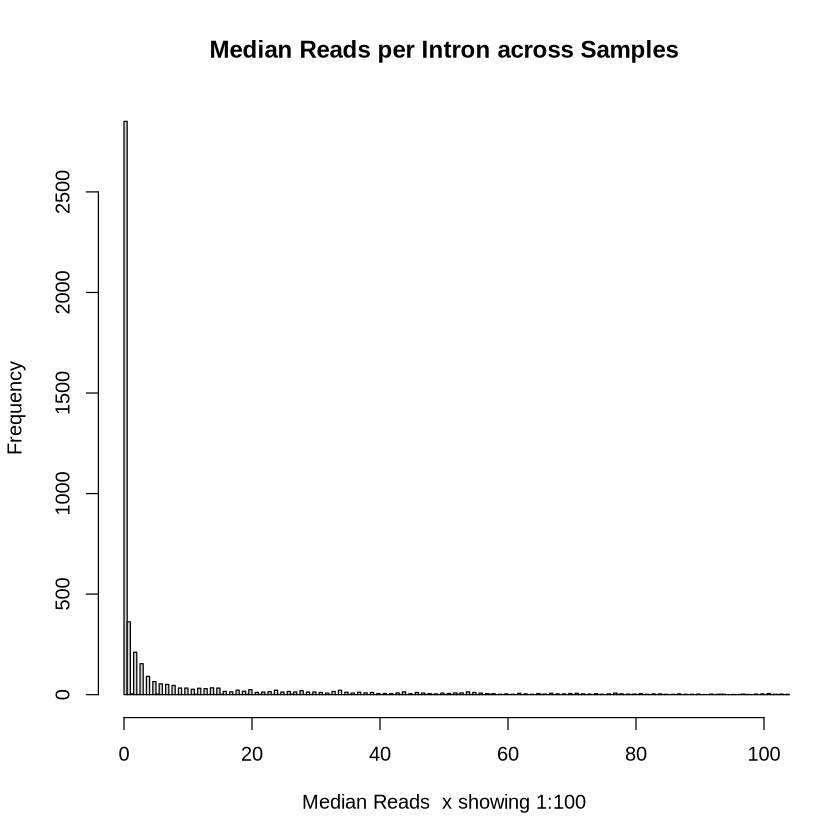

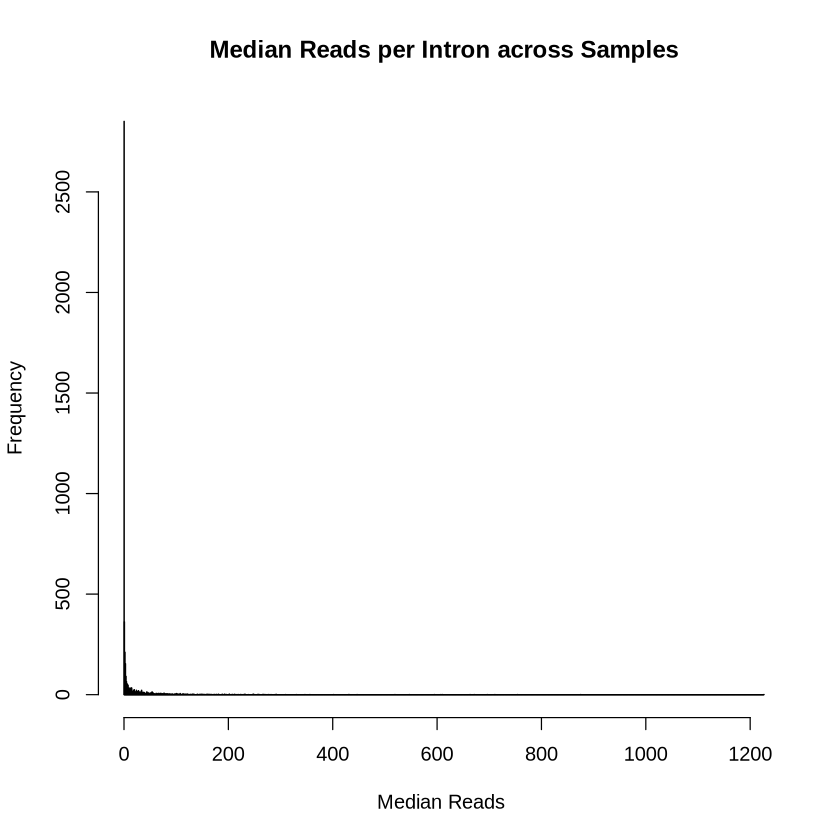

In [5]:
# step1

df_sam <-df %>% 
  select(-1) %>% 
  apply(1, median) %>% sample(.,5000)

hist(df_sam, breaks = 3000, main = "Median Reads per Intron across Samples", xlab = "Median Reads  x showing 1:100", xlim = c(0,100))
hist(df_sam, breaks = 3000, main = "Median Reads per Intron across Samples", xlab = "Median Reads ")

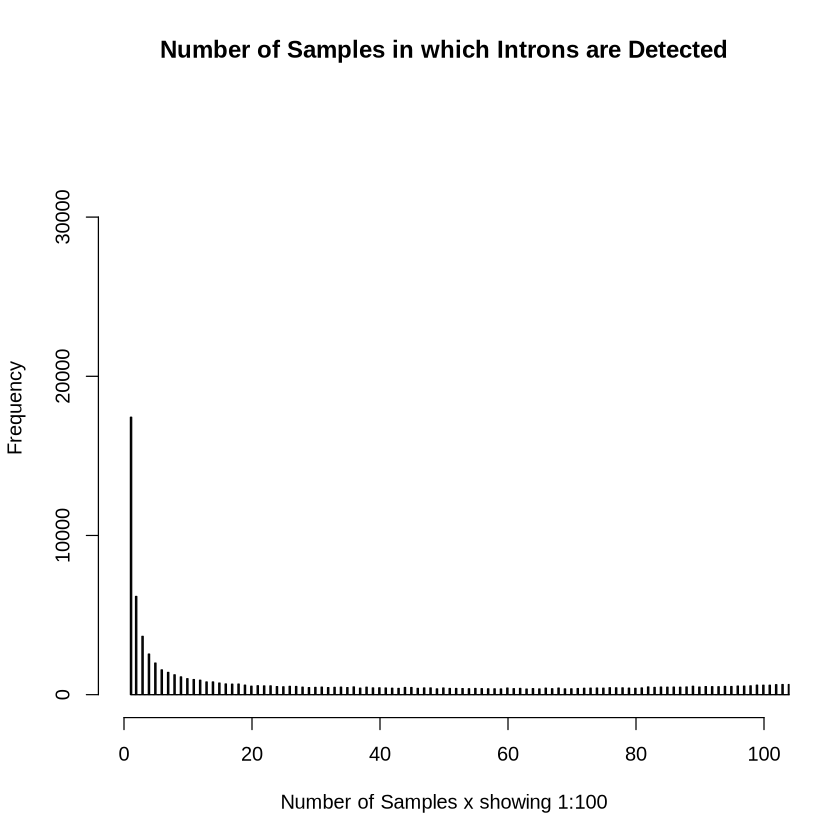

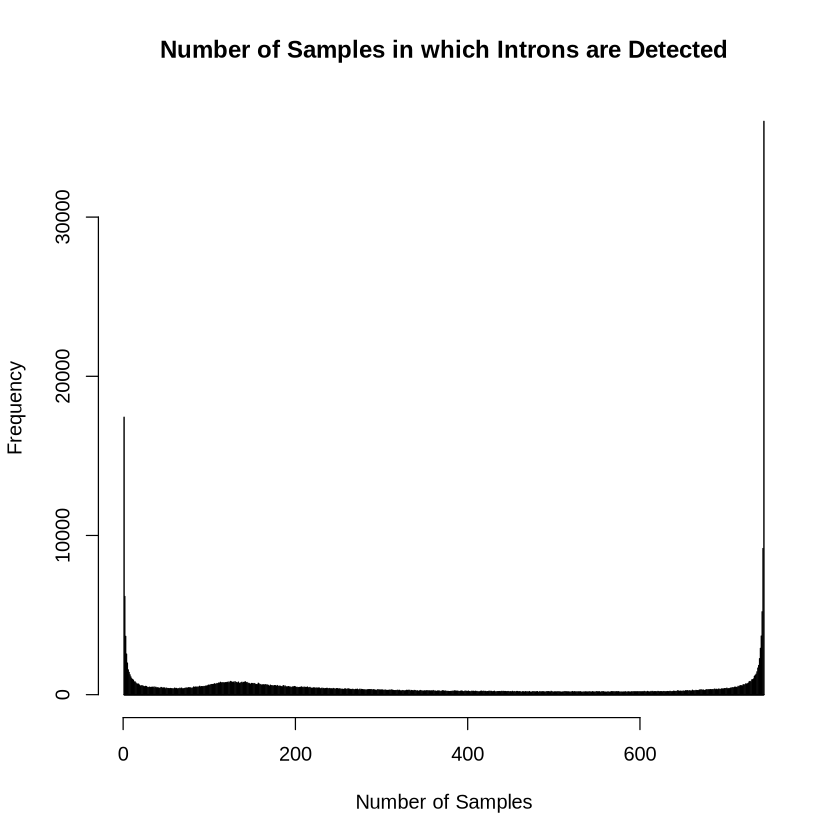

In [6]:
# step2
df_count <- df %>% 
  select(-1) %>% 
  apply(1, function(x) sum(x > 0)) 
hist(df_count, breaks = 3000, main = "Number of Samples in which Introns are Detected", xlab = "Number of Samples x showing 1:100", xlim = c(0,100))
hist(df_count, breaks = 3000, main = "Number of Samples in which Introns are Detected", xlab = "Number of Samples")


## filter raw data with min `m` samples with at least `n` reads each

[1] 351484

[1] 314370

[1] 0.8944077

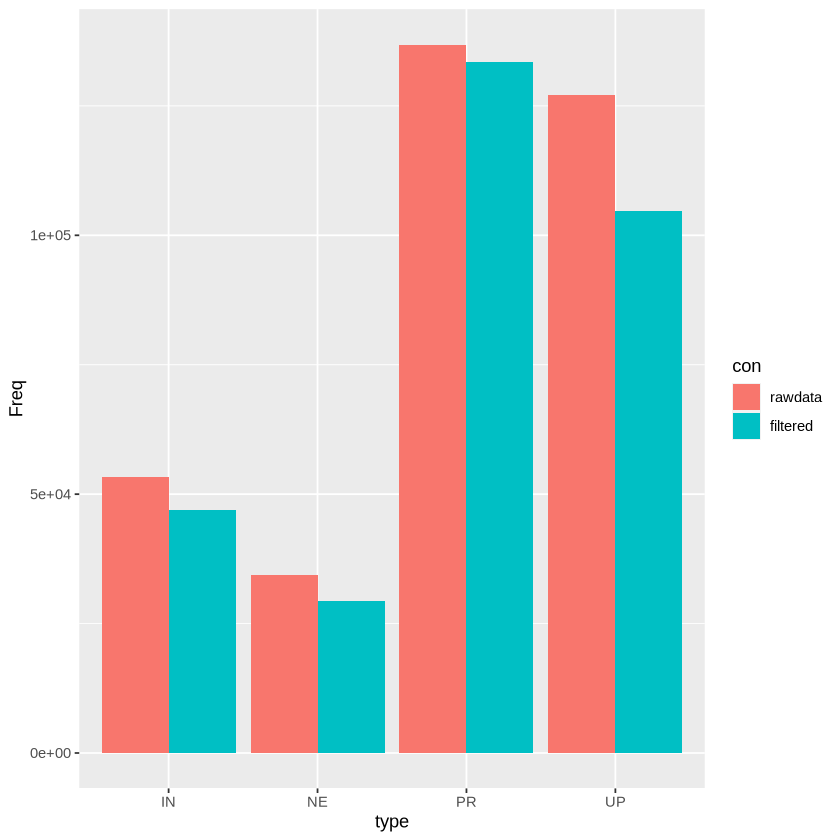

In [8]:
min_count = 1
min_sample = 10
#filter raw data with min 10 samples with at least 5 reads each
# Assuming 'df' is your dataframe with the first column being intron information and the rest being sample counts

# Step 1: Create a logical matrix where TRUE indicates that the intron has at least 5 reads in a sample
# logical_matrix <- df %>% 
#   select(-1) %>%
#   map_df(~.x >= 5)
logical_matrix <- as.data.frame(apply(df[,-1], 2, function(x) x >= min_count))

# Step 2: Sum the logical matrix by row to get the number of samples with at least 5 reads for each intron
samples_with_min_reads <- rowSums(logical_matrix)

# Step 3: Filter introns that are present in at least 10 samples with at least 5 reads
introns_to_keep <- which(samples_with_min_reads >= min_sample)

# Step 4: Subset the dataframe to keep only the desired introns
filtered_df <- df[introns_to_keep, ]

nrow(df)
nrow(filtered_df)
nrow(filtered_df)/nrow(df)

# Now 'filtered_df' contains only the introns that are present in at least 10 samples with at least 5 reads each
type_info1<- (df$chrom %>% str_split(.,":",simplify = T) %>% .[,5] %>% table)
type_info1 <- type_info1 %>% as.data.frame%>% mutate(con = "rawdata")

type_info2 <- (filtered_df$chrom %>% str_split(.,":",simplify = T) %>% .[,5] %>% table)
type_info2 <- type_info2 %>% as.data.frame%>% mutate(con = "filtered")

type_info <- rbind(type_info1,type_info2)
colnames(type_info)[1]<- 'type'
type_info$con <- factor(type_info$con,levels = c("rawdata","filtered"))
library(ggplot2)

ggplot(type_info, aes(x=type, y= Freq,group=con,  fill= con))+
  geom_bar(stat='identity',position = position_dodge())

In [9]:
filtered_counts <- counts %>% filter(chrom %in% filtered_df$chrom)
fwrite(filtered_df, "/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_AC_2024/output/leafcutter2/ROSMAP_AC_perind_numers.counts.noise_by_intron.QCed_minc1_mins10.gz", sep = ' ')
fwrite(filtered_counts, "/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_AC_2024/output/leafcutter2/ROSMAP_AC_perind.counts.noise_by_intron.QCed_minc1_mins10.gz", sep = ' ')


## add constitutive introns 

In [6]:
library(data.table)
library(dplyr)
library(ggplot2)
library(tidyr)

# Function to calculate ECDF data
calculate_ecdf <- function(df, min_reads_cutoffs, dataset_name) {
  cutoff_data <- lapply(min_reads_cutoffs, function(cutoff) {
    df %>%
      select(-1) %>%
      apply(1, function(x) sum(x >= cutoff))
  })
  
  ecdf_data <- map_df(min_reads_cutoffs, function(cutoff, data) {
    tibble(
      sample_count = data[[which(min_reads_cutoffs == cutoff)]],
      cutoff = as.factor(cutoff)
    )
  }, data = cutoff_data) %>%
    arrange(cutoff, sample_count) %>%
    group_by(cutoff) %>%
    mutate(ecdf = ecdf(sample_count)(sample_count), dataset = dataset_name)
  
  return(ecdf_data)
}

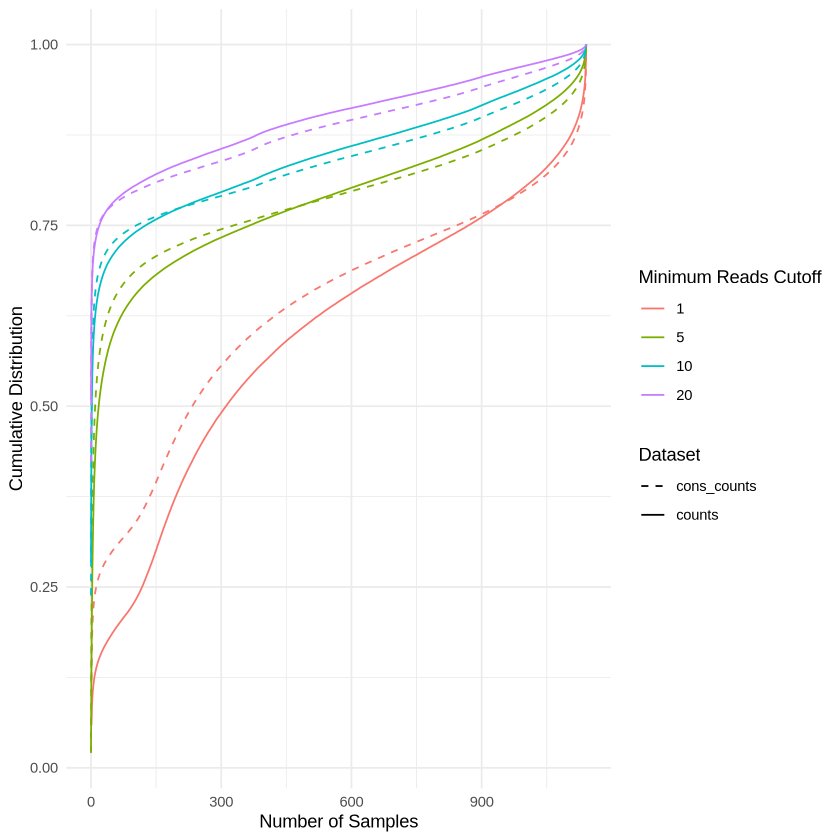

In [7]:
# Read in the data
nums_cons <- fread("/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_AC_2024/output/leafcutter2_const/ROSMAP_AC_const_perind_numers.constcounts.noise_by_intron.gz")
#nums <- fread("~/Google Drive/My Drive/analysis/ROSMAP_AC_perind_numers.counts.noise_by_intron.gz")

# Set cutoffs
min_reads_cutoffs <- c(1, 5, 10, 20) # Adjust as required

# Calculate ECDF for each dataset
ecdf_data1 <- calculate_ecdf(nums_cons, min_reads_cutoffs, 'cons_counts')
ecdf_data2 <- calculate_ecdf(nums, min_reads_cutoffs, 'counts')

# Combine the data
combined_ecdf_data <- rbind(ecdf_data1, ecdf_data2)

# Plot the ECDF
ggplot(combined_ecdf_data, aes(x = sample_count, y = ecdf, color = cutoff, linetype = dataset)) +
  geom_line() +
  labs(x = "Number of Samples", y = "Cumulative Distribution", color = "Minimum Reads Cutoff", linetype = "Dataset") +
  theme_minimal() +
  scale_linetype_manual(values = c("counts" = "solid", "cons_counts" = "dashed"))

### cluster cleaning

In [2]:
counts %>% head

ERROR: Error in counts %>% head: could not find function "%>%"


In [ ]:
addLabels <- function(dt) {
  pid_split <- str_split(dt$phenotype_id, ":")
  dt$itype <- map_chr(pid_split, ~ .x[5])
  dt$clu <- map_chr(pid_split, ~ .x[4])
  dt$clu <- str_extract(dt$clu, "clu_[0-9]+")

  dt <- dt[, ctype := paste(sort(unique(itype)), collapse = ","), by = clu][]
  return(dt)
}